# 3.2 Clasificación y regresión


Los problemas que requieren una respuesta *cuantitativa* (un valor numérico) son **regresión**; los que requieren una respuesta *cualitativa* (booleana o categórica) son **clasificación**. Muchos métodos estadísticos pueden aplicarse a ambos tipos de problema.

La clasificación **binaria** tiene dos clases de salida. Suelen terminar siendo «A» y «no A». Ejemplos: «sismo» o «no sismo = ruido». La clasificación **multiclase** es la que tiene más de dos clases.

La clasificación aquí requiere que conozcamos las etiquetas: es una forma de *aprendizaje supervisado*.

## 1. Algoritmos de clasificación
Existen varios algoritmos clasificadores, que resumimos antes de practicar. Para cada uno, hágase tres preguntas en este orden: qué pregunta geocientífica responde, cuál es la idea estadística detrás y cuándo se ajusta a sus datos. Los nombres de scikit-learn son lo de menos — un agente de programación puede suplirlos.

* **Regresión logística** (*logistic regression*): ¿Es potable esta muestra de agua? ¿Esta forma de onda es un sismo o ruido? La regresión logística traza una frontera recta a través del espacio de características (variables explicativas, *features*) y convierte la distancia de una muestra a esa frontera en una probabilidad entre 0 y 1. Como produce una probabilidad y no solo una etiqueta, conviene en problemas donde la respuesta debe alimentar un pronóstico, y sus coeficientes pueden leerse como el efecto de cada característica. La lección 3.6 está dedicada a ella.

* **Análisis discriminante lineal (LDA)**: Dadas la densidad y la susceptibilidad magnética, ¿un espécimen de roca es granito o basalto? LDA trata cada clase como una nube de muestras de datos con su propio centro pero una dispersión compartida, y encuentra la dirección del espacio de características a lo largo de la cual los centros de las clases se separan con mayor limpieza en relación con la dispersión interna de cada clase; la frontera de decisión es una recta entre las nubes proyectadas. Donde PCA (capítulo 2.12) busca la dirección de mayor varianza sin considerar las clases, LDA busca la dirección que mejor distingue las clases. Como estima solo las medias de clase y una dispersión común, se comporta bien con colecciones etiquetadas pequeñas — unas pocas decenas de especímenes por tipo de roca — donde los modelos flexibles se sobreajustan.

* **Naive Bayes (NB)**: ¿Cuál de tres tipos de roca produjo con mayor plausibilidad estas propiedades medidas? Naive Bayes (clasificador bayesiano ingenuo) pregunta, para cada clase, qué tan probables serían los valores de características observados si la muestra perteneciera a esa clase — tratando cada característica como si fuera independiente de las demás — y asigna la clase que hace más probable la observación. Ese supuesto de independencia rara vez es cierto en mediciones geofísicas (la temperatura y la humedad se mueven juntas), y aun así el método suele clasificar bien, aprende de muy pocas muestras de datos y casi no tiene nada que ajustar.

* **K vecinos más cercanos (KNN)**: Si las muestras de entrenamiento más parecidas a esta son en su mayoría basalto, llámela basalto. KNN almacena los datos de entrenamiento y clasifica una muestra nueva por votación entre sus *K* vecinos más cercanos en el espacio de características. «Más cercano» depende de las unidades — una densidad en kg/m³ arrasaría con una susceptibilidad medida en valores SI diminutos —, así que las características en unidades mixtas deben reescalarse primero a rangos comparables. El método no supone nada sobre la forma de la frontera entre clases, pero se debilita a medida que crece el número de características, y cada predicción exige una búsqueda en el conjunto de entrenamiento almacenado.

* **Máquina de vectores de soporte (SVM)**: ¿Este sismograma es una explosión de cantera o un sismo tectónico, cuando solo existen unos cientos de ejemplos etiquetados a mano? La SVM encuentra la frontera que separa las clases con el colchón más ancho — el *margen* —, de modo que una muestra de datos cercana a la frontera necesitaría una perturbación grande para cambiar de lado. Los núcleos (*kernels*: función de base radial, polinomial) permiten que esa frontera se curve. La SVM fue el método de elección cuando los catálogos geocientíficos etiquetados contenían cientos de eventos y no millones, y sigue siendo fuerte en ese régimen de pocas muestras; devuelve una decisión, no una probabilidad.

* **Bosque aleatorio (RF)**: ¿Esta combinación de pendiente, lluvia y litología marca una ladera como propensa a deslizamientos? Un bosque aleatorio hace crecer muchos árboles de decisión, cada uno sobre un subconjunto aleatorio de las muestras de datos y de las características, y asigna la clase que gana la votación entre los árboles; promediar muchos árboles ruidosos reduce la varianza de cualquiera de ellos por separado. Tolera características en unidades mixtas sin reescalar y reporta qué características impulsaron la clasificación, que a menudo es la pregunta geocientífica de interés. Sus fracciones de voto parecen probabilidades pero no son probabilidades calibradas — la lección 3.6 vuelve sobre eso.

* **Redes neuronales artificiales (ANN)**: Cuando la frontera entre clases es demasiado enredada para una recta, un colchón o una votación — distinguir el tremor eruptivo del ruido del viento en un espectrograma —, las redes neuronales componen capas de funciones simples en fronteras de forma casi arbitraria. Esa flexibilidad se paga en datos: necesitan muchas más muestras etiquetadas que los métodos anteriores, y sus decisiones son más difíciles de interpretar. El capítulo 4 las trata en profundidad.

Algunos clasificadores manejan el caso multiclase de manera nativa (descenso de gradiente estocástico - SGD; clasificación por bosque aleatorio; Naive Bayes). Otros son clasificadores estrictamente binarios (regresión logística, clasificador de máquina de vectores de soporte - SVM). En la práctica, scikit-learn envuelve automáticamente los clasificadores binarios en un esquema uno-contra-el-resto (*one-vs-rest*), de modo que también funcionan en problemas multiclase.


## Ejercicio
Crearemos un conjunto de datos sintético que representa tres tipos de roca: granito, basalto y arenisca. Cada tipo tendrá valores característicos de densidad y susceptibilidad magnética.

🖥️ [**Diapositivas — Sesión 12 (lun 26 oct)**](https://geo-smart.github.io/mlgeo-book/slides/2026/lec12_supervision_concepts.html)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix

Generar los datos sintéticos

In [2]:

# Set random seed for reproducibility
np.random.seed(42)

# Number of samples per class
n_samples = 100

# Generate features for Granite
granite_density = np.random.normal(2.9, 0.2, n_samples)
granite_susceptibility = np.random.normal(0.0001, 0.0001, n_samples)
granite_label = ['Granite'] * n_samples

# Generate features for Basalt
basalt_density = np.random.normal(3.2, 0.2, n_samples)
basalt_susceptibility = np.random.normal(0.001, 0.0005, n_samples)
basalt_label = ['Basalt'] * n_samples

# Generate features for Sandstone
sandstone_density = np.random.normal(2.4, 0.2, n_samples)
sandstone_susceptibility = np.random.normal(0.00005, 0.00005, n_samples)
sandstone_label = ['Sandstone'] * n_samples

# Combine data
density = np.concatenate([granite_density, basalt_density, sandstone_density])
susceptibility = np.concatenate([granite_susceptibility, basalt_susceptibility, sandstone_susceptibility])
labels = np.concatenate([granite_label, basalt_label, sandstone_label])

# Create DataFrame
data = pd.DataFrame({
    'Density': density,
    'Magnetic Susceptibility': susceptibility,
    'Lithology': labels
})
data.head()

,Density,Magnetic Susceptibility,Lithology
0,2.999343,-0.000042,Granite
1,2.872347,0.000058,Granite
2,3.029538,0.000066,Granite
3,3.204606,0.000020,Granite
4,2.853169,0.000084,Granite


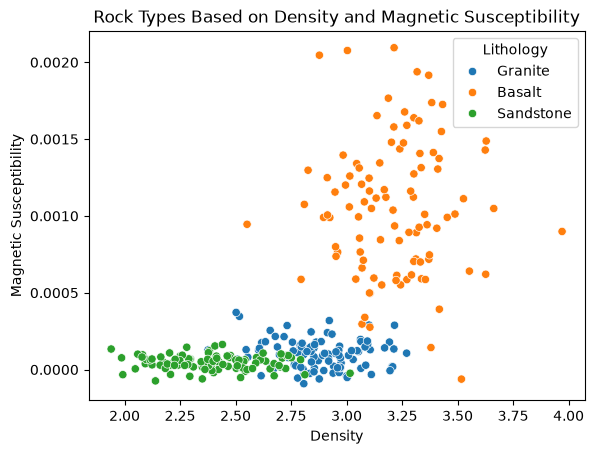

In [3]:
import seaborn as sns

sns.scatterplot(
    x='Density',
    y='Magnetic Susceptibility',
    hue='Lithology',
    data=data
)
plt.title('Rock Types Based on Density and Magnetic Susceptibility')
plt.show()

Divida los datos en tres partes: entrenamiento, validación y prueba (60/20/20). Cada conjunto tiene un solo trabajo. El conjunto de entrenamiento ajusta los parámetros del modelo. El conjunto de validación compara modelos y ajusta hiperparámetros. El conjunto de prueba se toca una sola vez, al final, para la estimación honesta y definitiva del desempeño.

In [4]:
X = data[['Density', 'Magnetic Susceptibility']]
y = data['Lithology']

# First split off the test set (20%), then split the rest into train (60%) and validation (20%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42
)
print(f"train: {len(X_train)}, validation: {len(X_val)}, test: {len(X_test)}")

train: 180, validation: 60, test: 60


```{admonition} Establezca siempre un modelo de referencia
:class: tip
Todo modelo debe superar a un predictor trivial antes de que su score signifique algo. Aquí el predictor trivial elige la clase más frecuente; como las tres clases están balanceadas, su exactitud es de alrededor de 1/3.
```

In [5]:
baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(X_train, y_train)
print(f"Majority-class baseline accuracy on validation set: {baseline.score(X_val, y_val):.3f}")

Majority-class baseline accuracy on validation set: 0.333


Entrene un clasificador k-NN sobre los datos de entrenamiento. El número de vecinos $k$ es un hiperparámetro: probamos varios valores, calificamos cada uno sobre el conjunto de validación y nos quedamos con el mejor.

In [6]:
best_k, best_acc = None, 0.0
for k in [1, 3, 5, 9, 15]:
    clf = KNeighborsClassifier(n_neighbors=k)
    clf.fit(X_train, y_train)
    acc = clf.score(X_val, y_val)
    print(f"k = {k:2d}   validation accuracy = {acc:.3f}")
    if acc > best_acc:
        best_k, best_acc = k, acc
print(f"\nBest k on the validation set: {best_k}")

k =  1   validation accuracy = 0.683
k =  3   validation accuracy = 0.667
k =  5   validation accuracy = 0.700
k =  9   validation accuracy = 0.767
k = 15   validation accuracy = 0.750

Best k on the validation set: 9


Evalúe el desempeño sobre el conjunto de prueba, una sola vez, con el $k$ elegido.

In [7]:
classifier = KNeighborsClassifier(n_neighbors=best_k)
classifier.fit(X_train, y_train)

y_pred = classifier.predict(X_test)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[12  4  0]
 [ 4 18  0]
 [ 1  3 18]]
              precision    recall  f1-score   support

      Basalt       0.71      0.75      0.73        16
     Granite       0.72      0.82      0.77        22
   Sandstone       1.00      0.82      0.90        22

    accuracy                           0.80        60
   macro avg       0.81      0.80      0.80        60
weighted avg       0.82      0.80      0.80        60




## 2. Algoritmos de regresión

Los modelos de regresión predicen valores numéricos continuos a partir de las entradas.

Ejemplos de aplicación en las geociencias incluyen predecir niveles freáticos a partir de registros climáticos y de bombeo, estimar propiedades del suelo a partir de mediciones espectrales, y la reducción de escala estadística de temperatura y precipitación.

### 2.1 Regresión lineal

Sea $y$ el dato y $\hat{y}$ el valor predicho del dato. Una regresión lineal general puede formularse como

$\hat{y} = w_0 + w_1 x_1 + ... + w_n x_n = h_w (\mathbf{x})$.

$\mathbf{\hat{y}} = \mathbf{G} \mathbf{w}$.

$y$ es un vector de datos de longitud $m$, $\mathbf{x}$ es un vector de características de longitud $n$. $\mathbf{w}$ es un vector de parámetros del modelo; $h_w$ se denomina la *función hipótesis* o el *modelo* con los parámetros $w$. En el caso más simple de una regresión lineal con el tiempo, la formulación queda:

$\hat{y} = w_0 + w_1 t$,

donde $x_1 = t$ es la característica temporal.

Para evaluar qué tan bien se desempeña el modelo, calcularemos un *score de pérdida*, o *residual*. Es el resultado de aplicar una función de *pérdida* (también llamada de *costo* u *objetivo*) a la predicción y a los datos. La *función de costo* más básica es el **error cuadrático medio (MSE, *Mean Square Error*)**:

$MSE(\mathbf{x},h_w) = \frac{1}{m} \sum_{i=1}^{m} \left( h_w(\mathbf{x})_i - y_i  \right)^2  = \frac{1}{m} \sum_{i=1}^{m} \left( \hat{y}_i - y_i  \right)^2 $, en el caso de una regresión lineal.

La *ecuación normal* es la solución de la regresión lineal que minimiza el MSE.

$\mathbf{w} = \left( \mathbf{x}^T\mathbf{x} \right)^{-1} \mathbf{x}^T \mathbf{y}$

Esto se compara con el problema inverso clásico planteado por $\mathbf{d} = \mathbf{G} \mathbf{m}$.

$\mathbf{m} = \left( \mathbf{G}^T\mathbf{G} \right)^{-1} \mathbf{G}^T \mathbf{d} $

Puede resolverse con el módulo de álgebra lineal de Numpy. Si $\left( \mathbf{x}^T\mathbf{x} \right) $ es singular y no puede invertirse, puede calcularse una matriz de rango menor llamada la *pseudoinversa* mediante la descomposición en valores singulares. En una clase anterior también usamos la función de Scikit-learn ``sklearn.linear_model.LinearRegression``, que es la implementación de la *pseudoinversa*. Practicamos abajo cómo usar estas inversiones estándar:


### Otros algoritmos comunes

Más allá de la regresión lineal ordinaria, los algoritmos de regresión comunes incluyen:

* **Regresión polinomial**: ¿Qué tan rápido se seca el suelo a medida que sube la temperatura, cuando la respuesta se curva en lugar de seguir una recta? Agregar términos cuadráticos y cruzados de las características permite que la misma maquinaria de mínimos cuadrados ajuste una curva. Los grados bajos suelen bastar; los grados altos oscilan sin control fuera del rango de las muestras de entrenamiento, lo cual es peligroso cuando al modelo se le preguntará por condiciones que nunca vio.

* **Regresión de vectores de soporte (SVR)**: La forma de regresión de la SVM. Ajusta una función ignorando los residuales menores que una tolerancia elegida, de modo que solo las muestras de datos que caen fuera de esa banda moldean el ajuste. Eso la hace tolerante al ruido de medición y menos influenciable por un solo sensor con picos.

* **Regresión por bosque aleatorio**: ¿Cuánta lluvia cayó, dadas estas características de radar? Un ensamble de árboles de decisión cuyas predicciones se promedian; captura relaciones curvas e interacciones entre características, sin necesidad de reescalar unidades mixtas. Una advertencia: un bosque no puede predecir más allá del rango de sus objetivos de entrenamiento, así que nunca pronosticará una lluvia mayor que cualquiera con la que fue entrenado.

* **Árboles con potenciación de gradiente** (*gradient-boosted trees*): Árboles agregados en secuencia, cada uno ajustando los residuales que dejaron los anteriores. En datos geocientíficos tabulares — mediciones de estaciones, registros de pozo, atributos de catálogo —, los árboles potenciados suelen ser la opción más exacta, al precio de más hiperparámetros que ajustar y un mayor apetito por el sobreajuste que un bosque aleatorio.

* **Redes neuronales**: Ajustan relaciones de forma casi arbitraria, con suficientes muestras de datos. Para los conjuntos pequeños y estructurados de este capítulo, los métodos más simples de arriba suelen igualarlas; el capítulo 4 cubre cuándo toman la delantera.


### Ejercicio
Objetivo: predecir el contenido de humedad del suelo a partir de factores ambientales.

Simularemos la humedad del suelo influida por la temperatura y la humedad del aire.

In [8]:
# Seeded random generator for reproducibility
rng = np.random.default_rng(42)

# Number of samples
n_samples = 300

# Generate environmental variables
temperature = rng.uniform(15, 35, n_samples)  # in degrees Celsius
humidity = rng.uniform(30, 90, n_samples)     # in percentage

# Generate soil moisture as a function of temperature and humidity,
# with a mild quadratic term in temperature
soil_moisture = (
    0.5 * humidity
    - 0.3 * temperature
    - 0.02 * (temperature - 25) ** 2
    + rng.normal(0, 2, n_samples)
)

# Create DataFrame
data = pd.DataFrame({
    'Temperature': temperature,
    'Humidity': humidity,
    'Soil Moisture': soil_moisture
})
data.head()

,Temperature,Humidity,Soil Moisture
0,30.479121,76.739781,31.121639
1,23.777569,38.073133,11.368374
2,32.171958,62.164082,21.128622
3,28.947361,60.853372,16.611001
4,16.883547,81.454329,32.031869


La función verdadera ahora tiene una no linealidad suave (el término cuadrático en la temperatura). Esto importa para el ejercicio: la selección de modelos solo tiene sentido cuando la función verdadera es desconocida. Si los datos fueran exactamente lineales, la regresión lineal ganaría por construcción y comparar modelos no enseñaría nada.

Visualización de los datos

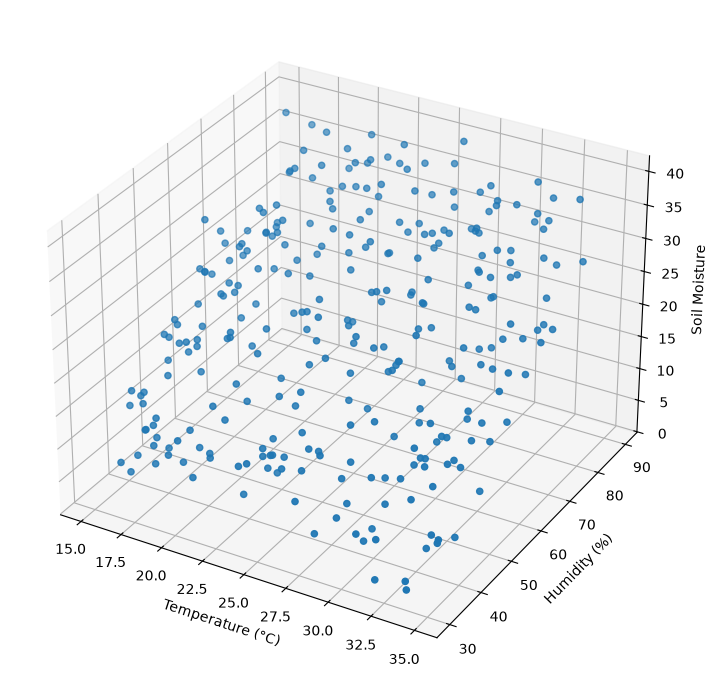

In [9]:

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(data['Temperature'], data['Humidity'], data['Soil Moisture'])
ax.set_xlabel('Temperature (°C)')
ax.set_ylabel('Humidity (%)')
ax.set_zlabel('Soil Moisture')
plt.tight_layout()
plt.show()

Divida los datos en conjuntos de entrenamiento, validación y prueba (60/20/20), con los mismos papeles que antes.

In [10]:
X = data[['Temperature', 'Humidity']]
y = data['Soil Moisture']

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42
)
print(f"train: {len(X_train)}, validation: {len(X_val)}, test: {len(X_test)}")

train: 180, validation: 60, test: 60


Empiece con el modelo de referencia trivial: predecir la media de los objetivos de entrenamiento para cada muestra. Cualquier modelo de regresión debe superarlo.

In [11]:
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_squared_error, r2_score

baseline = DummyRegressor(strategy="mean")
baseline.fit(X_train, y_train)
y_val_base = baseline.predict(X_val)
print(f"Baseline (mean prediction) on validation set: "
      f"MSE = {mean_squared_error(y_val, y_val_base):.2f}, "
      f"R2 = {r2_score(y_val, y_val_base):.3f}")

Baseline (mean prediction) on validation set: MSE = 87.15, R2 = -0.012


Ahora el modelo real más simple: la regresión lineal.

In [12]:
from sklearn.linear_model import LinearRegression

linreg = LinearRegression()
linreg.fit(X_train, y_train)
y_val_lin = linreg.predict(X_val)
mse_lin = mean_squared_error(y_val, y_val_lin)
print(f"Linear regression on validation set: "
      f"MSE = {mse_lin:.2f}, R2 = {r2_score(y_val, y_val_lin):.3f}")

Linear regression on validation set: MSE = 5.09, R2 = 0.941


A continuación, un modelo polinomial de grado 2: un *pipeline* de scikit-learn (`Pipeline`) — la cadena de modelado que encadena preprocesamiento y estimador en un solo objeto ajustable — que expande las características en todos los términos de grado 2 y luego ajusta una regresión lineal sobre ellos.

In [13]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures

polyreg = Pipeline([
    ("poly", PolynomialFeatures(degree=2)),
    ("linreg", LinearRegression()),
])
polyreg.fit(X_train, y_train)
y_val_poly = polyreg.predict(X_val)
mse_poly = mean_squared_error(y_val, y_val_poly)
print(f"Degree-2 polynomial on validation set: "
      f"MSE = {mse_poly:.2f}, R2 = {r2_score(y_val, y_val_poly):.3f}")

Degree-2 polynomial on validation set: MSE = 4.80, R2 = 0.944


Elija el modelo con el menor MSE de validación y luego reporte su desempeño una sola vez sobre el conjunto de prueba.

In [14]:
if mse_poly < mse_lin:
    best_name, best_model = "degree-2 polynomial", polyreg
else:
    best_name, best_model = "linear regression", linreg

y_test_pred = best_model.predict(X_test)
print(f"Selected model: {best_name}")
print(f"Test set: MSE = {mean_squared_error(y_test, y_test_pred):.2f}, "
      f"R2 = {r2_score(y_test, y_test_pred):.3f}")

Selected model: degree-2 polynomial
Test set: MSE = 4.02, R2 = 0.947


El modelo polinomial gana en el conjunto de validación porque la función verdadera contiene un término cuadrático que el modelo lineal no puede representar; el score de prueba, usado una sola vez, confirma esa elección.